In [69]:
%reload_ext autoreload
%autoreload 2


In [70]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

In [119]:
data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
S0 = np.where(brain_mask, S0, 0.)
x_o = data_norm[:, :, 28:29].squeeze()
S_o = S0[:, :, 28:29].squeeze()

/tmp/ipykernel_3983080/1639302203.py:12: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_3983080/1639302203.py:12: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


In [9]:
import numpy as np

import jax
import jax.numpy as jnp

from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx


In [10]:
from omegaconf import OmegaConf
res_folder = "/home/macke/mgloeckler90/dmri/results/dmri_ball_sticks_shared_param_real"
config_path = res_folder + "/2025-04-09_10-55-54/0/.hydra/config.yaml"
cfg = OmegaConf.load(config_path)
print(cfg)

{'name': 'dmri_ball_sticks_shared_param_real', 'seed': 0, 'use_wandb': True, 'wandb': {'project': 'dmri_ball_sticks_shared_param', 'entity': None}, 'simulator': {'sim_type': {'name': 'Ball3StickSharedDiffusivity'}, 'acquisition_scheme': {'name': 'hcp', 'params': {'num_acquisitions': 105}}, 'prior_mask_alpha': 1.0, 'prior_mask_beta': 1.0}, 'model': {'embedding_net': {'name': 'DMRIEmbeddingConfig', 'params': {'num_layers': 2, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'bvals_embed_dim': 12, 'signals_embed_dim': 12, 'bvec_repeats': 4, 'log_transform_signals': False}}, 'inference_net': {'name': 'DMRIThetaInferenceConfig', 'params': {'num_layers': 6, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'context_dim': 64, 'dropout_rate': None}}, 'model_selection_net': {'name': 'DMRIModelSelectionAmortizedPriorConfig', 'params': {'num_layers': 4, 'num_heads': 4, 'widening_factor': 4, 'attn_size': 16, 'dropout_rate': None, 'context_dim': 64, 'mask_prior_dim'

In [11]:
from dmri.train.build_model import build_model
from dmri.train.build_simulator import build_simulator


sim_type, simulator = build_simulator(cfg)
model = build_model(cfg, sim_type)
model.eval()

graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)

In [12]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [13]:
# Learning rate scheduler and optimizer
import optax
optimizer_cfg = cfg.train.optimizer
optimizer_type = getattr(optax, optimizer_cfg.optimizer)
scheduler_type = getattr(optax, optimizer_cfg.scheduler)
use_ema = optimizer_cfg.get("ema", False)
use_adaptive_clip = optimizer_cfg.get("adaptive_gradient_clipping", False)
grad_transforms = []
if use_adaptive_clip:
    grad_clip = optax.adaptive_grad_clip(
        optimizer_cfg.get("gradient_clip_value", 10.0)
    )
    grad_transforms.append(grad_clip)
scheduler = scheduler_type(**optimizer_cfg.scheduler_params)
optimizer = optimizer_type(scheduler)
grad_transforms.append(optimizer)
if use_ema:
    grad_transforms.append(optax.ema(optimizer_cfg.get("ema_decay", 0.8)))

# Initialize optimizer
optimizer = optax.chain(*grad_transforms)

In [14]:
from dmri.train.checkpointing import CheckpointManager
checkpoint_dir = res_folder + "/checkpoints"
continue_training = True
checkpoint_manager = CheckpointManager(
        ckpt_dir=checkpoint_dir,
        max_to_keep=cfg.get("max_checkpoints", 3),
        keep_best=cfg.get("keep_best_checkpoint", True),
        recovery_threshold=cfg.get("recovery_threshold", float("inf")),
        continue_training=continue_training,
        use_async=cfg.get(
            "use_async_checkpointing", True
        ),  # Enable async checkpointing
    )

In [15]:
latest_step = checkpoint_manager.get_latest_step()
opt_state = optimizer.init(params)

In [16]:
checkpoint = checkpoint_manager.restore(
                step=latest_step, params=params, optimizer_state=opt_state,
            )

In [17]:
params = checkpoint["params"]

In [18]:
model = nnx.merge(graphdef, params, static, state)
model.eval()

In [19]:
nnx.display(model)

In [86]:
p_mask,masks, theta, x_o, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

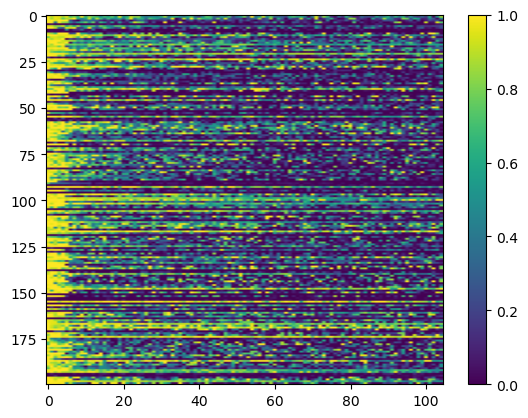

In [87]:
import matplotlib.pyplot as plt

p_mask,masks, theta, x_os, acq = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

plt.imshow(x_o, aspect='auto', vmin=0, vmax=1)
plt.colorbar()

In [96]:
#idx = 2
idx = 26
masks[idx]

Array([ True,  True,  True,  True, False,  True, False], dtype=bool)

In [97]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.1]))

In [98]:
mask_true= masks[idx]

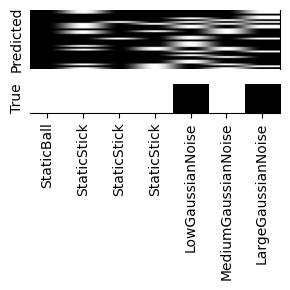

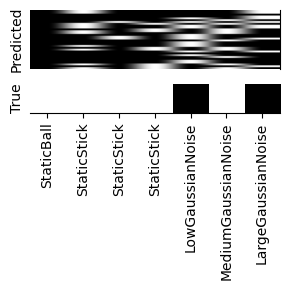

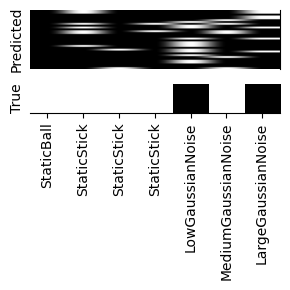

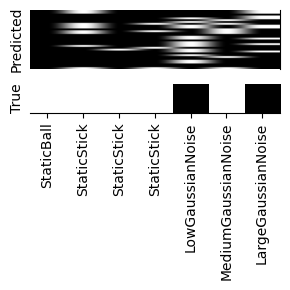

In [99]:
import matplotlib.pyplot as plt

for t in [0.01, 0.1, 0.5, 0.9]:
    mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 32), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([t]))
    fig = plt.figure(figsize=(3, 3))

    # Create a grid with 90% height for the predicted mask and 10% height for the true mask
    grid = plt.GridSpec(2, 1, height_ratios=[4, 2])

    # Plot predicted mask on top subplot
    ax1 = plt.subplot(grid[0])
    ax1.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax1.set_ylabel('Predicted')
    ax1.set_xticks([])  # Hide x-ticks
    ax1.set_yticks([])  # Hide y-ticks
    # Remove unnecessary spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)

    # Plot true mask on bottom subplot
    ax2 = plt.subplot(grid[1])
    ax2.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
    ax2.set_ylabel('True')
    #ax2.set_xlabel('Model Type')

    # Set x-tick labels
    model_labels = [str(m).split(".")[-1].split("'")[0] for m in sim_type.model_types] + [str(m).split(".")[-1].split("'")[0] for m in sim_type.noise_types]
    ax2.set_xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)))
    ax2.set_xticklabels(model_labels, rotation=90)

    # Remove y-axis ticks
    ax2.set_yticks([])
    # Remove unnecessary spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.svg")
    # fig.savefig(f"../figures/mask_posterior_t={t}_idx={idx}.png")

In [53]:
from functools import partial

thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=80), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4, 5, 6)


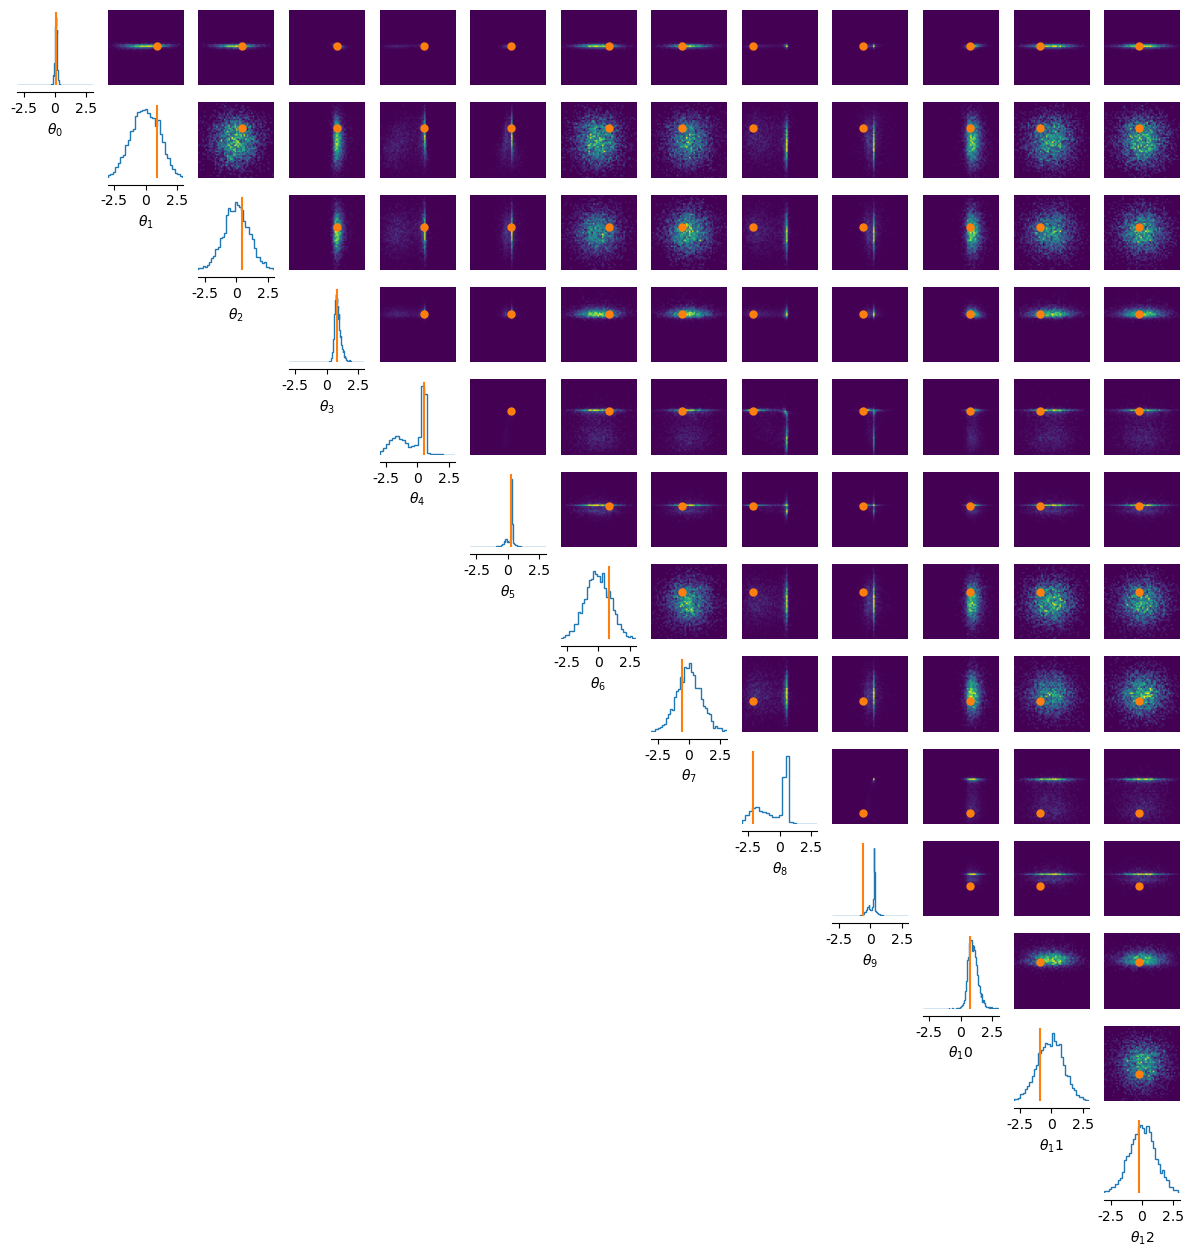

In [54]:
import sbi
from sbi.analysis.plot import pairplot

fig,axes = pairplot(thetas_post, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(15, 15))
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.svg")
# fig.savefig(f"../figures/posterior_pairplot_idx{idx}.png")

In [58]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))

In [59]:
ll = loglikelihood(theta[idx])

Text(0, 0.5, 'MRI Signal')

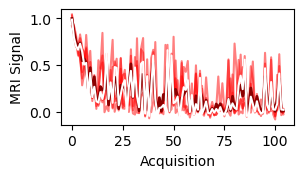

In [60]:
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(3, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [61]:
def log_posterior(theta):
    return loglikelihood(theta) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def log_q(theta):
    return model.log_prob_theta(theta, acq.bvals[idx], acq.bvecs[idx], x_os[idx], masks[idx], num_steps=128, max_noise=80)

@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(log_posterior)(thetas)
    logq = jax.vmap(log_q)(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [73]:
effectve_sample_size(thetas_post)

Array(3.048, dtype=float32)

In [120]:
idx = np.argsort(bvals)
bvals = bvals[idx]
bvecs = bvecs[idx]
x_o = x_o[...,idx]


In [121]:
np.quantile(x_o, [0.01, 0.999])

array([0.   , 1.382])

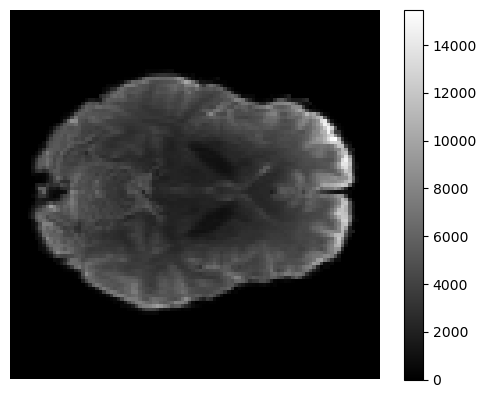

In [122]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

fig, ax = plt.subplots(1)
l = ax.imshow(S_o, cmap='gray', origin='lower')
ax.set_axis_off()
plt.colorbar(l)
#ax.set_title('HCP coronal slice B0 with ROI')

In [123]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))
x_o_flat = x_o.reshape(-1, x_o.shape[-1])

In [143]:
brain_mask_slice = brain_mask[:,:,28:29].squeeze()
brain_mask_slice_flat = brain_mask_slice.reshape(-1)

In [187]:
sample_mask_per_x= jax.jit(jax.vmap(lambda k, x: model.sample_mask(k, acq.bvals, acq.bvecs, x, mask_prior=jnp.array([0.3])), in_axes=(0,0)))

mask = sample_mask_per_x(jax.random.split(jax.random.key(0), x_o_flat.shape[0]), x_o_flat)#astype(jnp.float32)
mask_count = mask.astype(jnp.float32)
only_balls = (mask[...,0] & ~(mask[...,1:3].any(axis=-1))).astype(jnp.float32)
ball_1_stick = (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 1)).astype(jnp.float32)
ball_2_stick = (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 2)).astype(jnp.float32)
ball_3_stick = (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 3)).astype(jnp.float32)
one_stick = ((mask[...,1:3].sum(axis=-1) == 2)).astype(jnp.float32)

for i in range(1,501):
    mask = sample_mask_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat)
    mask_count += mask.astype(jnp.float32)
    only_balls += (mask[...,0] & ~(mask[...,1:3].any(axis=-1))).astype(jnp.float32)
    ball_1_stick += (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 1)).astype(jnp.float32)
    ball_2_stick += (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 2)).astype(jnp.float32)
    ball_3_stick += (mask[...,0] & (mask[...,1:3].sum(axis=-1) == 3)).astype(jnp.float32)
    one_stick += ((mask[...,1:3].sum(axis=-1) == 1)).astype(jnp.float32)
p_models = mask_count / 500
p_only_balls = only_balls / 500
p_ball_1_stick = ball_1_stick / 500
p_ball_2_stick = ball_2_stick / 500
p_ball_3_stick = ball_3_stick / 500
p_one_stick = one_stick / 500

p_models = p_models.reshape(x_o.shape[:-1] + (p_models.shape[-1],))

In [188]:
p_only_balls = p_only_balls.reshape(x_o.shape[:-1])
p_ball_1_stick = p_ball_1_stick.reshape(x_o.shape[:-1])
p_ball_2_stick = p_ball_2_stick.reshape(x_o.shape[:-1])
p_ball_3_stick = p_ball_3_stick.reshape(x_o.shape[:-1])
one_stick = one_stick.reshape(x_o.shape[:-1])


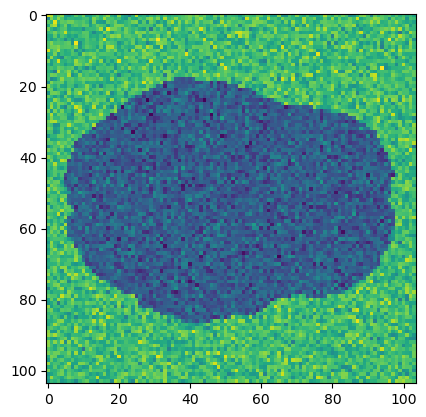

In [194]:
plt.imshow(one_stick)

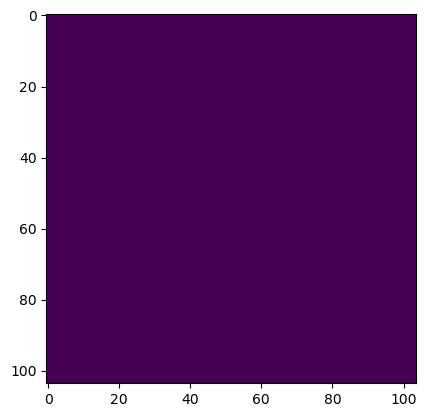

In [163]:
plt.imshow(p_ball_1_stick)

In [138]:
model_mask = jnp.array([True, True, True, True, False, True, False], dtype=jnp.bool)
sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=128, max_noise=80), in_axes=(0,0)))

thetas = []
for i in range(2):
    thetas.append(sample_theta_per_x(jax.random.split(jax.random.key(i), x_o_flat.shape[0]), x_o_flat))


(0, 1, 2, 3, 4, 5, 6)


In [139]:
x_o_flat.shape

(10816, 105)

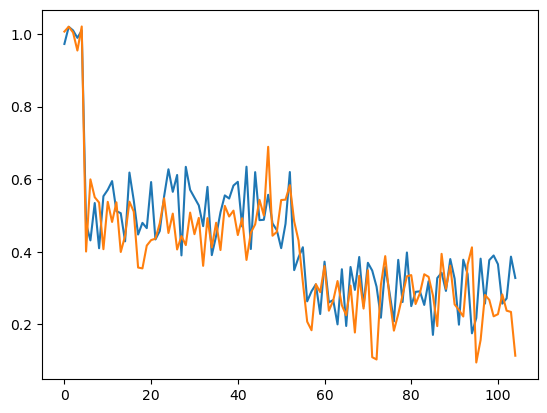

In [141]:

def sim_theta(key, theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    x_pred = simulator.signal(acq, rng=key)
    return x_pred

x_preds = jax.vmap(sim_theta)(jax.random.split(jax.random.key(0), thetas[0].shape[0]), thetas[1])
i = 4005
plt.plot(x_o_flat[i], label="data")
plt.plot(x_preds[i], label="pred")